In [1]:
import numpy as np

# For reproducible random numbers
np.random.seed(42)

# (a) Create a 6×4 matrix of random integers (0–100)
scores = np.random.randint(0, 101, size=(6, 4))
print("========== Original Scores ==========")
print(scores)

# (b) Normalize each column to the range [0, 1] using broadcasting
col_min = scores.min(axis=0)
col_max = scores.max(axis=0)

normalized_scores = (scores - col_min) / (col_max - col_min)

print("\n========== Column Minimum ==========")
print(col_min)

print("\n========== Column Maximum ==========")
print(col_max)

print("\n========== Normalized Scores ==========")
print(normalized_scores)

# (c) Create a boolean mask for students averaging >= 60
average_scores = scores.mean(axis=1)
passing_mask = average_scores >= 60
passing_students = scores[passing_mask]

print("\n========== Average Score of Each Student ==========")
print(average_scores)

print("\n========== Passing Mask (Average >= 60) ==========")
print(passing_mask)

print("\n========== Passing Students ==========")
print(passing_students)

# (d) Replace scores below 40 with the column mean
column_mean = scores.mean(axis=0)

updated_scores = np.where(scores < 40, column_mean, scores)

print("\n========== Column Mean ==========")
print(column_mean)

print("\n========== Scores After Replacing Values Below 40 ==========")
print(updated_scores)

# (e) Compute the dot product using a random weight vector
weights = np.random.rand(4)

weighted_scores = np.dot(normalized_scores, weights)

print("\n========== Random Weight Vector ==========")
print(weights)

print("\n========== Weighted Scores ==========")
print(weighted_scores)

========== Original Scores ==========
[[51 92 14 71]
 [60 20 82 86]
 [74 74 87 99]
 [23  2 21 52]
 [ 1 87 29 37]
 [ 1 63 59 20]]

========== Column Minimum ==========
[ 1  2 14 20]

========== Column Maximum ==========
[74 92 87 99]

========== Normalized Scores ==========
[[0.68493151 1.         0.         0.64556962]
 [0.80821918 0.2        0.93150685 0.83544304]
 [1.         0.8        1.         1.        ]
 [0.30136986 0.         0.09589041 0.40506329]
 [0.         0.94444444 0.20547945 0.21518987]
 [0.         0.67777778 0.61643836 0.        ]]

========== Average Score of Each Student ==========
[57.   62.   83.5  24.5  38.5  35.75]

========== Passing Mask (Average >= 60) ==========
[False  True  True False False False]

========== Passing Students ==========
[[60 20 82 86]
 [74 74 87 99]]

========== Column Mean ==========
[35.         56.33333333 48.66666667 60.83333333]

========== Scores After Replacing Values Below 40 ==========
[[51.         92.         48.66666667 71.   

In [3]:
import pandas as pd

# Load the Titanic dataset
df = pd.read_csv("/content/train.csv")

# Display the first 10 rows
print("========== First 10 Rows ==========")
print(df.head(10))

# Display the last 5 rows
print("\n========== Last 5 Rows ==========")
print(df.tail(5))

# Display 8 random rows
print("\n========== Random Sample (8 Rows) ==========")
print(df.sample(8, random_state=42))

# Display dataset shape
print("\n========== Dataset Shape ==========")
print(df.shape)

# Display dataset information
print("\n========== Dataset Information ==========")
df.info()

# Display data types of each column
print("\n========== Data Types ==========")
print(df.dtypes)

# Display list of column names
print("\n========== Column Names ==========")
print(df.columns.tolist())

# Count numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).shape[1]

# Count categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).shape[1]

# Count columns that contain missing values
columns_with_missing = df.isnull().any().sum()

# Count total missing cells
total_missing = df.isnull().sum().sum()

# Print summary
print("\n========== Dataset Summary ==========")
print(f"Number of Numerical Columns : {numerical_columns}")
print(f"Number of Categorical Columns : {categorical_columns}")
print(f"Columns with Missing Values : {columns_with_missing}")
print(f"Total Missing Cells : {total_missing}")

========== First 10 Rows ==========
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                           

In [4]:
# Install missingno
!pip install missingno

========== Missing Value Summary ==========
             Missing Values  Missing Percentage
PassengerId               0                0.00
Survived                  0                0.00
Pclass                    0                0.00
Name                      0                0.00
Sex                       0                0.00
Age                     177               19.87
SibSp                     0                0.00
Parch                     0                0.00
Ticket                    0                0.00
Fare                      0                0.00
Cabin                   687               77.10
Embarked                  2                0.22


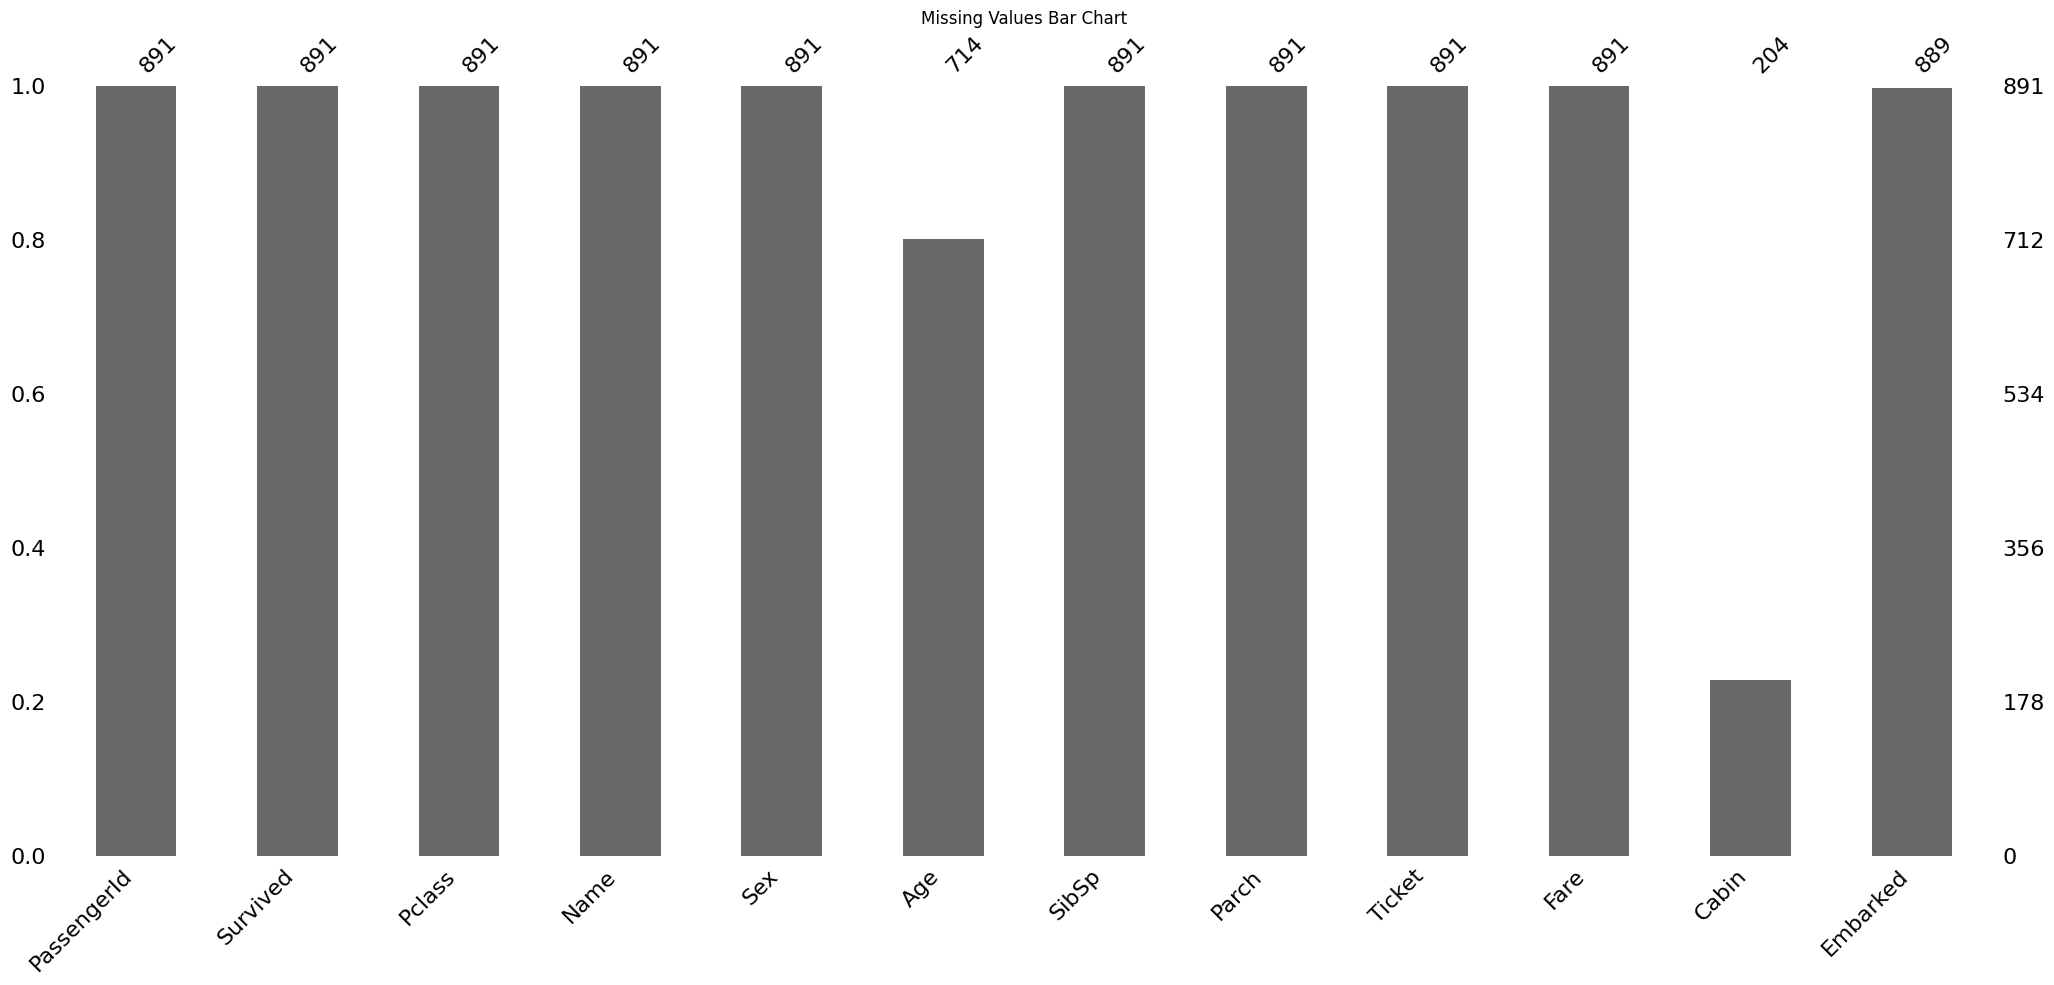


========== Top 3 Columns with Most Missing Values ==========
          Missing Values  Missing Percentage
Cabin                687               77.10
Age                  177               19.87
Embarked               2                0.22


In [5]:
import missingno as msno
import matplotlib.pyplot as plt

# Count missing values in each column
missing_count = df.isnull().sum()

# Calculate missing percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine both into one DataFrame
missing_summary = missing_count.to_frame(name='Missing Values')
missing_summary['Missing Percentage'] = missing_percentage.round(2)

# Display missing value summary
print("========== Missing Value Summary ==========")
print(missing_summary)

# Visualize missing values
plt.figure(figsize=(10,6))
msno.bar(df)
plt.title("Missing Values Bar Chart")
plt.show()

# Find the top 3 columns with the most missing values
top_missing = missing_summary.sort_values(
    by='Missing Values',
    ascending=False
).head(3)

print("\n========== Top 3 Columns with Most Missing Values ==========")
print(top_missing)

In [6]:
import pandas as pd

# Store original data types
old_dtypes = df.dtypes

print("========== Data Types Before Conversion ==========")
print(old_dtypes)

# Convert Survived to Category
df['Survived'] = df['Survived'].astype('category')

# Convert Pclass to Category
df['Pclass'] = df['Pclass'].astype('category')

# Convert Sex to Category
df['Sex'] = df['Sex'].astype('category')

# Convert Embarked to Category
df['Embarked'] = df['Embarked'].astype('category')

# Store new data types
new_dtypes = df.dtypes

print("\n========== Data Types After Conversion ==========")
print(new_dtypes)

# Create a before/after comparison table
comparison = pd.DataFrame({
    'Column Name': old_dtypes.index,
    'Old Data Type': old_dtypes.values,
    'New Data Type': new_dtypes.values
})

print("\n========== Before vs After Data Types ==========")
print(comparison)

# Display updated dataset information
print("\n========== Updated Dataset Information ==========")
df.info()

========== Data Types Before Conversion ==========
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

========== Data Types After Conversion ==========
PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked       category
dtype: object

========== Before vs After Data Types ==========
    Column Name Old Data Type New Data Type
0   PassengerId         int64         int64
1      Survived         int64      category
2        Pclass         int64      category
3          Name        object        object
4           Sex        object      c

In [7]:
# Check missing values before cleaning
print("========== Missing Values Before Cleaning ==========")
print(df.isnull().sum())

# -----------------------------
# Fill Age using median grouped by Pclass and Sex
# -----------------------------
df['Age'] = df['Age'].fillna(
    df.groupby(['Pclass', 'Sex'], observed=True)['Age'].transform('median')
)

# -----------------------------
# Fill Embarked with mode
# -----------------------------
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# -----------------------------
# Create has_cabin feature
# -----------------------------
df['has_cabin'] = df['Cabin'].notnull().astype(int)

# -----------------------------
# Drop Cabin column
# -----------------------------
df.drop(columns='Cabin', inplace=True)

# -----------------------------
# Verify missing values
# -----------------------------
print("\n========== Missing Values After Cleaning ==========")
print(df.isnull().sum())

print("\n========== Total Missing Values ==========")
print(df.isnull().sum().sum())

# -----------------------------
# Cleaning Summary
# -----------------------------
summary = pd.DataFrame({
    'Column': ['Age', 'Embarked', 'Cabin'],
    'Strategy Used': [
        'Filled with Group Median (Pclass + Sex)',
        'Filled with Mode',
        'Created has_cabin then Dropped Cabin'
    ]
})

print("\n========== Cleaning Strategy Summary ==========")
print(summary)

========== Missing Values Before Cleaning ==========
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

========== Missing Values After Cleaning ==========
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
has_cabin      0
dtype: int64

========== Total Missing Values ==========
0

========== Cleaning Strategy Summary ==========
     Column                            Strategy Used
0       Age  Filled with Group Median (Pclass + Sex)
1  Embarked                         Filled with Mode
2     Cabin     Created has_cabin then Dropped Cabin



========== Age ==========
Q1           : 21.50
Q3           : 36.00
IQR          : 14.50
Lower Fence  : -0.25
Upper Fence  : 57.75
Outliers     : 33

========== Fare ==========
Q1           : 7.91
Q3           : 31.00
IQR          : 23.09
Lower Fence  : -26.72
Upper Fence  : 65.63
Outliers     : 116


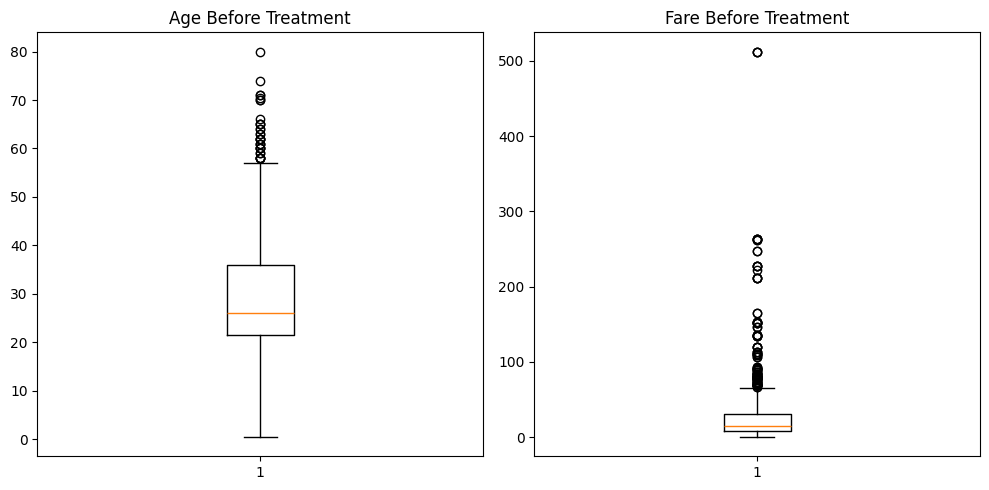


99th Percentile Fare: 249.00622000000035


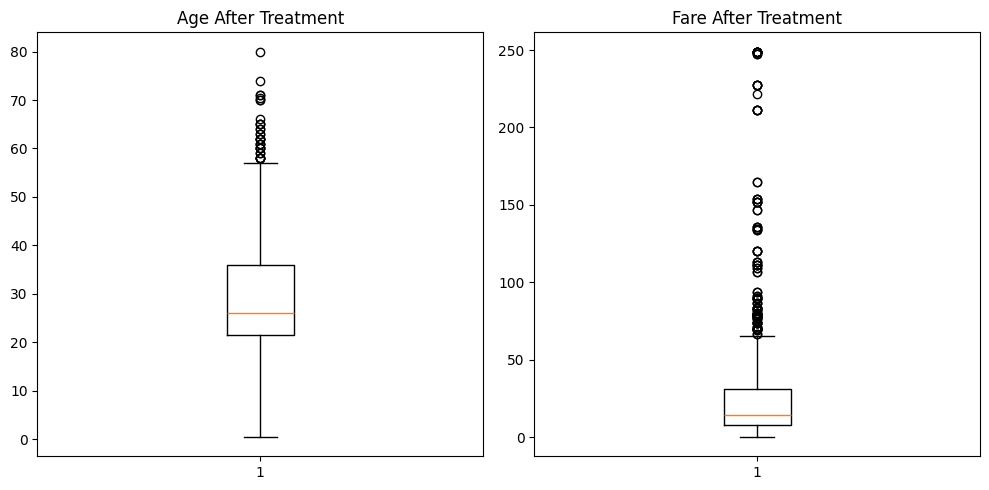


Decision:
- Fare outliers were capped at the 99th percentile.
- Age outliers were kept because they represent real passenger ages.


In [8]:
import matplotlib.pyplot as plt

# ---------------------------------------------
# Function to calculate IQR and outliers
# ---------------------------------------------
def detect_outliers(column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    outliers = df[(df[column_name] < lower_fence) | (df[column_name] > upper_fence)]

    print(f"\n========== {column_name} ==========")
    print(f"Q1           : {Q1:.2f}")
    print(f"Q3           : {Q3:.2f}")
    print(f"IQR          : {IQR:.2f}")
    print(f"Lower Fence  : {lower_fence:.2f}")
    print(f"Upper Fence  : {upper_fence:.2f}")
    print(f"Outliers     : {len(outliers)}")

# Detect outliers
detect_outliers("Age")
detect_outliers("Fare")

# ---------------------------------------------
# Boxplots BEFORE treatment
# ---------------------------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(df["Age"])
plt.title("Age Before Treatment")

plt.subplot(1,2,2)
plt.boxplot(df["Fare"])
plt.title("Fare Before Treatment")

plt.tight_layout()
plt.show()

# ---------------------------------------------
# Cap Fare at the 99th percentile
# ---------------------------------------------
fare_cap = df["Fare"].quantile(0.99)

df["Fare"] = df["Fare"].clip(upper=fare_cap)

print("\n99th Percentile Fare:", fare_cap)

# ---------------------------------------------
# Boxplots AFTER treatment
# ---------------------------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(df["Age"])
plt.title("Age After Treatment")

plt.subplot(1,2,2)
plt.boxplot(df["Fare"])
plt.title("Fare After Treatment")

plt.tight_layout()
plt.show()

print("\nDecision:")
print("- Fare outliers were capped at the 99th percentile.")
print("- Age outliers were kept because they represent real passenger ages.")

In [10]:
# ---------------------------------------------
# Reload original dataset only to extract Deck
# ---------------------------------------------
original_df = pd.read_csv("/content/train.csv")

# ---------------------------------------------
# (a) Family Size
# ---------------------------------------------
df["family_size"] = df["SibSp"] + df["Parch"] + 1

# ---------------------------------------------
# (b) Is Alone
# ---------------------------------------------
df["is_alone"] = (df["family_size"] == 1).astype(int)

# ---------------------------------------------
# (c) Fare Per Person
# ---------------------------------------------
df["fare_per_person"] = df["Fare"] / df["family_size"]

# ---------------------------------------------
# (d) Extract Title from Name
# ---------------------------------------------
df["title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")

# Group rare titles
rare_titles = [
    "Lady", "Countess", "Capt", "Col", "Don",
    "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"
]

df["title"] = df["title"].replace(rare_titles, "Rare")

# ---------------------------------------------
# (e) Age Group
# ---------------------------------------------
df["age_group"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 60, 100],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)

# ---------------------------------------------
# (f) Deck
# ---------------------------------------------
df["deck"] = original_df["Cabin"].str[0]
df["deck"] = df["deck"].fillna("Unknown")

# ---------------------------------------------
# (g) Fare Bin
# ---------------------------------------------
df["fare_bin"] = pd.qcut(
    df["Fare"],
    q=4,
    labels=["Low", "Medium", "High", "VHigh"]
)

# ---------------------------------------------
# Print value counts
# ---------------------------------------------
print("========== Title ==========")
print(df["title"].value_counts())

print("\n========== Age Group ==========")
print(df["age_group"].value_counts())

print("\n========== Deck ==========")
print(df["deck"].value_counts())

print("\n========== Fare Bin ==========")
print(df["fare_bin"].value_counts())

print("\n========== Is Alone ==========")
print(df["is_alone"].value_counts())

# ---------------------------------------------
# Display first 10 rows
# ---------------------------------------------
new_features = [
    "family_size",
    "is_alone",
    "fare_per_person",
    "title",
    "age_group",
    "deck",
    "fare_bin"
]

print("\n========== First 10 Rows ==========")
print(df[new_features].head(10))

========== Title ==========
title
Mr              517
Miss            182
Mrs             125
Master           40
Rare             22
Mlle              2
Mme               1
Ms                1
the Countess      1
Name: count, dtype: int64

========== Age Group ==========
age_group
Adult     752
Child      68
Teen       45
Senior     26
Name: count, dtype: int64

========== Deck ==========
deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

========== Fare Bin ==========
fare_bin
Medium    224
Low       223
High      222
VHigh     222
Name: count, dtype: int64

========== Is Alone ==========
is_alone
1    537
0    354
Name: count, dtype: int64

========== First 10 Rows ==========
   family_size  is_alone  fare_per_person   title age_group     deck fare_bin
0            2         0          3.62500      Mr     Adult  Unknown      Low
1            2         0         35.6416

In [11]:
# ---------------------------------------------
# (a) Label Encode 'Sex'
# Male = 0, Female = 1
# ---------------------------------------------
df["sex_encoded"] = df["Sex"].map({"male": 0, "female": 1}).astype(int)

# ---------------------------------------------
# (b) One-Hot Encode 'Embarked'
# ---------------------------------------------
embarked_dummies = pd.get_dummies(
    df["Embarked"],
    prefix="Embarked",
    dtype=int
)

df = pd.concat([df, embarked_dummies], axis=1)

# ---------------------------------------------
# (c) One-Hot Encode 'title'
# Drop the most common category (Mr)
# ---------------------------------------------
title_dummies = pd.get_dummies(
    df["title"],
    prefix="Title",
    drop_first=True,
    dtype=int
)

df = pd.concat([df, title_dummies], axis=1)

# ---------------------------------------------
# (d) Ordinal Encode 'age_group'
# ---------------------------------------------
age_mapping = {
    "Child": 0,
    "Teen": 1,
    "Adult": 2,
    "Senior": 3
}

df["age_group_encoded"] = df["age_group"].map(age_mapping).astype(int)

# ---------------------------------------------
# (e) Ordinal Encode 'fare_bin'
# ---------------------------------------------
fare_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "VHigh": 3
}

df["fare_bin_encoded"] = df["fare_bin"].map(fare_mapping).astype(int)

# ---------------------------------------------
# Print Dataset Shape
# ---------------------------------------------
print("========== Dataset Shape ==========")
print(df.shape)

# ---------------------------------------------
# Number of Added Columns
# ---------------------------------------------
print("\nNumber of Columns After Encoding:", df.shape[1])

# ---------------------------------------------
# ML Feature List
# ---------------------------------------------
ml_features = [
    "Pclass",
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "family_size",
    "is_alone",
    "fare_per_person",
    "sex_encoded",
    "age_group_encoded",
    "fare_bin_encoded",
    "has_cabin"
]

# Add Embarked encoded columns
ml_features.extend(embarked_dummies.columns.tolist())

# Add Title encoded columns
ml_features.extend(title_dummies.columns.tolist())

print("\n========== ML Features ==========")
print(ml_features)

========== Dataset Shape ==========
(891, 33)

Number of Columns After Encoding: 33

========== ML Features ==========
['Pclass', 'Age', 'Fare', 'SibSp', 'Parch', 'family_size', 'is_alone', 'fare_per_person', 'sex_encoded', 'age_group_encoded', 'fare_bin_encoded', 'has_cabin', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rare', 'Title_the Countess']


In [12]:
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------
# Continuous numerical features to scale
# ---------------------------------------------
continuous_features = [
    "Age",
    "Fare",
    "fare_per_person",
    "family_size"
]

# ---------------------------------------------
# Mean and Standard Deviation BEFORE Scaling
# ---------------------------------------------
before_scaling = df[continuous_features].agg(["mean", "std"]).T
before_scaling.columns = ["Mean Before", "Std Before"]

# ---------------------------------------------
# Apply StandardScaler
# ---------------------------------------------
scaler = StandardScaler()

df[continuous_features] = scaler.fit_transform(df[continuous_features])

# ---------------------------------------------
# Mean and Standard Deviation AFTER Scaling
# ---------------------------------------------
after_scaling = df[continuous_features].agg(["mean", "std"]).T
after_scaling.columns = ["Mean After", "Std After"]

# ---------------------------------------------
# Comparison Table
# ---------------------------------------------
comparison = before_scaling.join(after_scaling)

print("========== Mean & Standard Deviation ==========")
print(comparison)

# ---------------------------------------------
# Create Final ML Dataset
# ---------------------------------------------
final_df = df.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket"
    ]
)

print("\n========== Final Dataset Information ==========")
final_df.info()

print("\n========== First 5 Rows ==========")
print(final_df.head())

# ---------------------------------------------
# Save Final Dataset
# ---------------------------------------------
final_df.to_csv("titanic_cleaned.csv", index=False)

print("\nDataset saved successfully as 'titanic_cleaned.csv'")

========== Mean & Standard Deviation ==========
                 Mean Before  Std Before    Mean After  Std After
Age                29.112424   13.304424  2.153160e-16   1.000562
Fare               31.224767   42.524125 -5.582266e-17   1.000562
fare_per_person    19.161062   28.386818  1.993666e-17   1.000562
family_size         1.904602    1.613459 -2.392400e-17   1.000562

========== Final Dataset Information ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Survived            891 non-null    category
 1   Pclass              891 non-null    category
 2   Sex                 891 non-null    category
 3   Age                 891 non-null    float64 
 4   SibSp               891 non-null    int64   
 5   Parch               891 non-null    int64   
 6   Fare                891 non-null    float64 
 7   Embarked     

Overall Survival Rate: 0.384

========== Survival by Pclass ==========
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


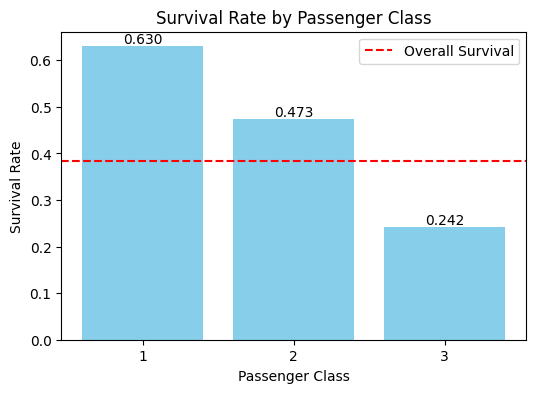


========== Survival by Sex ==========
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


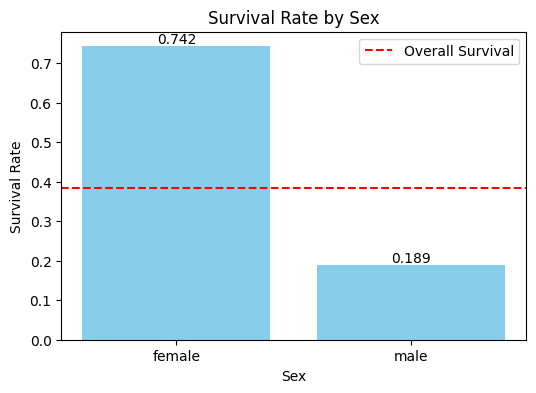


========== Survival by Pclass & Sex ==========
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135

========== Survival by Age Group ==========
age_group
Child     0.574
Teen      0.489
Adult     0.364
Senior    0.269
Name: Survived, dtype: float64


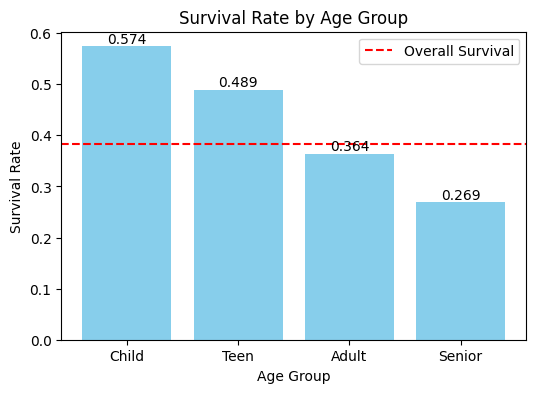


========== Survival by Is Alone ==========
is_alone
0    0.506
1    0.304
Name: Survived, dtype: float64


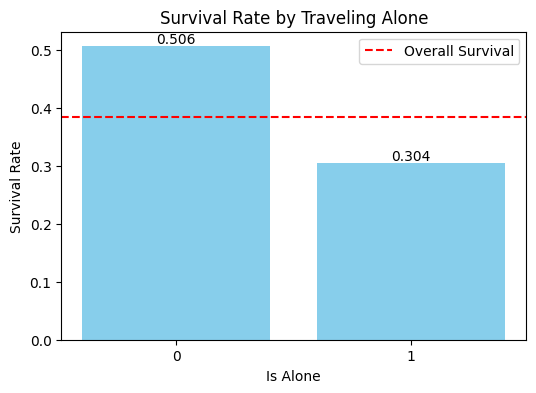


========== Survival by Embarked ==========
Embarked
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64


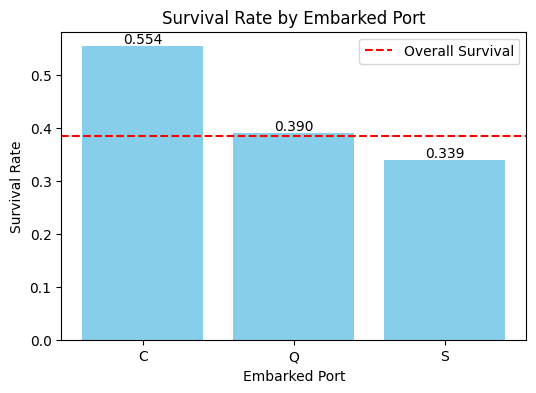

In [14]:
import matplotlib.pyplot as plt

# Overall survival rate
df["Survived"] = df["Survived"].astype(int)
overall_survival = df["Survived"].mean()

print(f"Overall Survival Rate: {overall_survival:.3f}")

# ---------------------------------------------
# Function to plot survival rates
# ---------------------------------------------
def plot_survival(data, title, xlabel):
    plt.figure(figsize=(6,4))

    bars = plt.bar(data.index.astype(str), data.values, color="skyblue")

    # Value labels
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.3f}",
            ha='center',
            va='bottom'
        )

    # Overall survival reference line
    plt.axhline(
        overall_survival,
        color='red',
        linestyle='--',
        label='Overall Survival'
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Survival Rate")
    plt.legend()
    plt.show()

# ---------------------------------------------
# (a) Survival by Pclass
# ---------------------------------------------
survival_pclass = df.groupby("Pclass", observed=True)["Survived"].mean().round(3)

print("\n========== Survival by Pclass ==========")
print(survival_pclass)

plot_survival(
    survival_pclass,
    "Survival Rate by Passenger Class",
    "Passenger Class"
)

# ---------------------------------------------
# (b) Survival by Sex
# ---------------------------------------------
survival_sex = df.groupby("Sex", observed=True)["Survived"].mean().round(3)

print("\n========== Survival by Sex ==========")
print(survival_sex)

plot_survival(
    survival_sex,
    "Survival Rate by Sex",
    "Sex"
)

# ---------------------------------------------
# (c) Survival by Pclass + Sex
# ---------------------------------------------
survival_pclass_sex = (
    df.groupby(["Pclass", "Sex"], observed=True)["Survived"]
      .mean()
      .unstack()
      .round(3)
)

print("\n========== Survival by Pclass & Sex ==========")
print(survival_pclass_sex)

# ---------------------------------------------
# (d) Survival by Age Group
# ---------------------------------------------
survival_age = df.groupby("age_group", observed=True)["Survived"].mean().round(3)

print("\n========== Survival by Age Group ==========")
print(survival_age)

plot_survival(
    survival_age,
    "Survival Rate by Age Group",
    "Age Group"
)

# ---------------------------------------------
# (e) Survival by Is Alone
# ---------------------------------------------
survival_alone = df.groupby("is_alone", observed=True)["Survived"].mean().round(3)

print("\n========== Survival by Is Alone ==========")
print(survival_alone)

plot_survival(
    survival_alone,
    "Survival Rate by Traveling Alone",
    "Is Alone"
)

# ---------------------------------------------
# (f) Survival by Embarked
# ---------------------------------------------
survival_embarked = df.groupby("Embarked", observed=True)["Survived"].mean().round(3)

print("\n========== Survival by Embarked ==========")
print(survival_embarked)

plot_survival(
    survival_embarked,
    "Survival Rate by Embarked Port",
    "Embarked Port"
)

In [15]:
# ---------------------------------------------
# Custom Functions
# ---------------------------------------------

# Percentage of fares greater than 50
def fare_above_50(x):
    return (x > 50).mean() * 100

# Interquartile Range (IQR)
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

# ---------------------------------------------
# GroupBy with agg()
# ---------------------------------------------
aggregation = df.groupby("Pclass", observed=True).agg({

    "Fare": [
        "mean",
        "median",
        "std",
        "min",
        "max",
        fare_above_50
    ],

    "Age": [
        "mean",
        "median",
        iqr
    ],

    "Survived": [
        "mean",
        "count"
    ]

})

print("========== Aggregated Statistics ==========")
print(aggregation)

# ---------------------------------------------
# Transform()
# ---------------------------------------------

# Average Fare of each Passenger Class
df["class_avg_fare"] = (
    df.groupby("Pclass", observed=True)["Fare"]
      .transform("mean")
)

# Survival Rate of each Passenger Class
df["class_survival_rate"] = (
    df.groupby("Pclass", observed=True)["Survived"]
      .transform("mean")
)

print("\n========== First 15 Rows ==========")

print(
    df[
        [
            "Pclass",
            "Fare",
            "class_avg_fare",
            "Survived",
            "class_survival_rate"
        ]
    ].head(15)
)

========== Aggregated Statistics ==========
           Fare                                                        \
           mean    median       std       min       max fare_above_50   
Pclass                                                                  
1       1.15034  0.683825  1.453492 -0.734696  5.124239           0.0   
2      -0.24853 -0.399404  0.315702 -0.734696  0.994705           0.0   
3      -0.41292 -0.545285  0.277131 -0.734696  0.901765           0.0   

             Age                      Survived        
            mean    median       iqr      mean count  
Pclass                                                
1       0.688732  0.668392  1.372495  0.629630   216  
2       0.056463  0.066750  0.977667  0.472826   184  
3      -0.324145 -0.309276  0.658045  0.242363   491  

========== First 15 Rows ==========
   Pclass      Fare  class_avg_fare  Survived  class_survival_rate
0       3 -0.564109        -0.41292         0             0.242363
1       1  0.942

========== Pivot Table 1 ==========
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


/tmp/ipykernel_526/863379530.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot1 = pd.pivot_table(


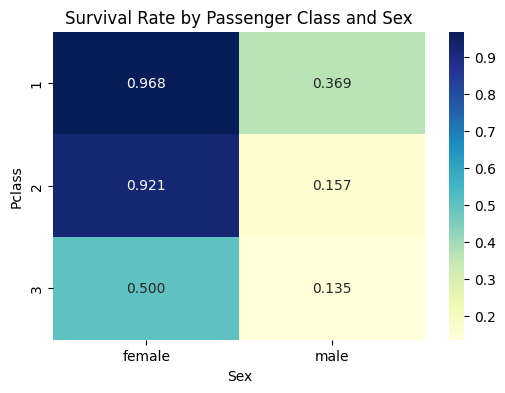

/tmp/ipykernel_526/863379530.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = pd.pivot_table(
/tmp/ipykernel_526/863379530.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = pd.pivot_table(
/tmp/ipykernel_526/863379530.py:40: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot3 = pd.pivot_table(



========== Pivot Table 2 ==========
            mean               count          
Pclass         1      2      3     1    2    3
age_group                                     
Child      0.750  1.000  0.404     4   17   47
Teen       1.000  0.667  0.323     8    6   31
Adult      0.642  0.414  0.218   187  157  408
Senior     0.294  0.250  0.200    17    4    5

========== Pivot Table 3 ==========
Pclass            1      2      3
title                            
Master        2.089 -0.123 -0.064
Miss          1.424 -0.429 -0.529
Mlle          0.663    NaN    NaN
Mme           0.896    NaN    NaN
Mr            0.263 -0.429 -0.549
Mrs           1.134 -0.123 -0.359
Ms              NaN -0.429    NaN
Rare          0.042 -0.429    NaN
the Countess  1.301    NaN    NaN


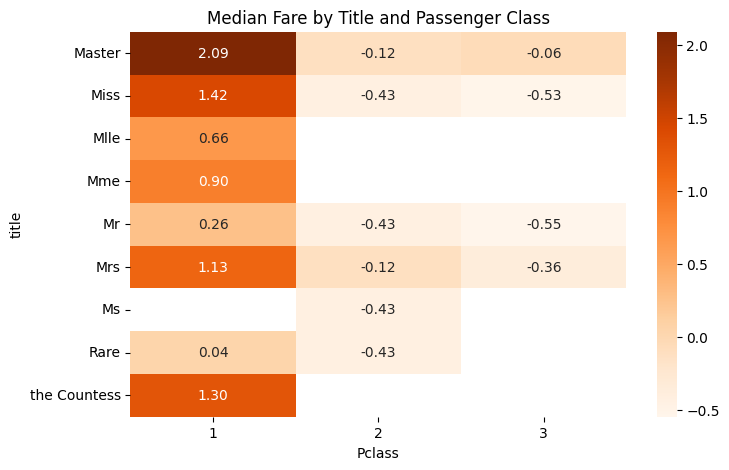

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------
# (a) Pivot Table: Survival Rate by Pclass and Sex
# ---------------------------------------------
pivot1 = pd.pivot_table(
    df,
    values="Survived",
    index="Pclass",
    columns="Sex",
    aggfunc="mean"
)

print("========== Pivot Table 1 ==========")
print(pivot1.round(3))

plt.figure(figsize=(6,4))
sns.heatmap(pivot1, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Survival Rate by Passenger Class and Sex")
plt.show()

# ---------------------------------------------
# (b) Pivot Table: Survival by Age Group and Pclass
# ---------------------------------------------
pivot2 = pd.pivot_table(
    df,
    values="Survived",
    index="age_group",
    columns="Pclass",
    aggfunc=["mean", "count"]
)

print("\n========== Pivot Table 2 ==========")
print(pivot2.round(3))

# ---------------------------------------------
# (c) Pivot Table: Median Fare by Title and Pclass
# ---------------------------------------------
pivot3 = pd.pivot_table(
    df,
    values="Fare",
    index="title",
    columns="Pclass",
    aggfunc="median"
)

print("\n========== Pivot Table 3 ==========")
print(pivot3.round(3))

plt.figure(figsize=(8,5))
sns.heatmap(pivot3, annot=True, fmt=".2f", cmap="Oranges")
plt.title("Median Fare by Title and Passenger Class")
plt.show()

CORRELATION MATRIX
                    Survived       Age     SibSp     Parch      Fare  \
Survived            1.000000 -0.059579 -0.035322  0.081629  0.273008   
Age                -0.059579  1.000000 -0.249854 -0.175526  0.133752   
SibSp              -0.035322 -0.249854  1.000000  0.414838  0.192869   
Parch               0.081629 -0.175526  0.414838  1.000000  0.248623   
Fare                0.273008  0.133752  0.192869  0.248623  1.000000   
has_cabin           0.316912  0.277022 -0.040460  0.036987  0.537609   
family_size         0.016639 -0.258456  0.890712  0.783111  0.256027   
is_alone           -0.203367  0.175529 -0.584471 -0.583398 -0.317699   
fare_per_person     0.246441  0.212362 -0.108133 -0.082618  0.803096   
sex_encoded         0.543351 -0.102706  0.114631  0.245489  0.212492   
Embarked_C          0.168240  0.041114 -0.059528 -0.011069  0.270714   
Embarked_Q          0.003650 -0.092418 -0.026354 -0.081228 -0.129890   
Embarked_S         -0.149683  0.022141  0.068

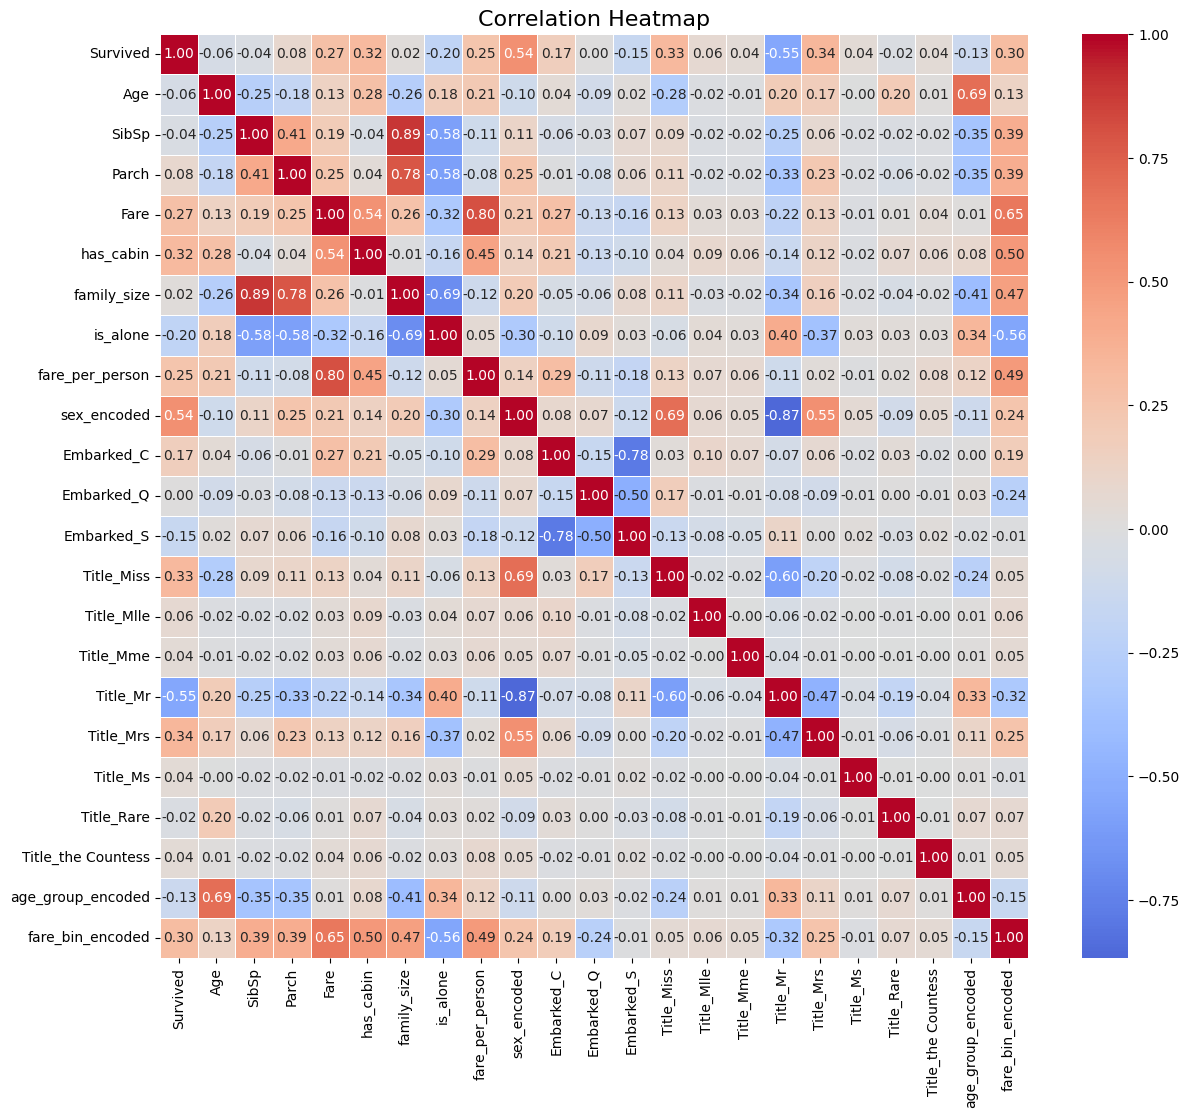


FEATURE CORRELATION WITH SURVIVED
Survived              1.000000
sex_encoded           0.543351
Title_Mrs             0.339040
Title_Miss            0.327093
has_cabin             0.316912
fare_bin_encoded      0.299357
Fare                  0.273008
fare_per_person       0.246441
Embarked_C            0.168240
Parch                 0.081629
Title_Mlle            0.060095
Title_Mme             0.042470
Title_the Countess    0.042470
Title_Ms              0.042470
family_size           0.016639
Embarked_Q            0.003650
Title_Rare           -0.021481
SibSp                -0.035322
Age                  -0.059579
age_group_encoded    -0.129832
Embarked_S           -0.149683
is_alone             -0.203367
Title_Mr             -0.549199
Name: Survived, dtype: float64

TOP 5 FEATURES
sex_encoded         0.543351
Title_Mrs           0.339040
Title_Miss          0.327093
has_cabin           0.316912
fare_bin_encoded    0.299357
Name: Survived, dtype: float64

NEAR ZERO CORRELATION
Parch 

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# --------------------------------------------------
if final_df["Survived"].dtype.name == "category":
    final_df["Survived"] = final_df["Survived"].astype(int)

# --------------------------------------------------
# Convert boolean columns to integers
# --------------------------------------------------
bool_cols = final_df.select_dtypes(include="bool").columns
final_df[bool_cols] = final_df[bool_cols].astype(int)

# --------------------------------------------------
# Select only numerical columns
# --------------------------------------------------
numerical_df = final_df.select_dtypes(include=["number"])

# --------------------------------------------------
# Correlation Matrix
# --------------------------------------------------
corr_matrix = numerical_df.corr()

print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

print(corr_matrix)

# --------------------------------------------------
# Heatmap
# --------------------------------------------------
plt.figure(figsize=(14,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

# --------------------------------------------------
# Correlation with Survived
# --------------------------------------------------
print("\n" + "=" * 60)
print("FEATURE CORRELATION WITH SURVIVED")
print("=" * 60)

survival_corr = corr_matrix["Survived"].sort_values(ascending=False)

print(survival_corr)

# --------------------------------------------------
# Top 5 Features
# --------------------------------------------------
print("\n" + "=" * 60)
print("TOP 5 FEATURES")
print("=" * 60)

top5 = survival_corr.drop(labels=["Survived"]).head(5)

print(top5)

# --------------------------------------------------
# Near Zero Correlation
# --------------------------------------------------
print("\n" + "=" * 60)
print("NEAR ZERO CORRELATION")
print("=" * 60)

near_zero = survival_corr[
    (survival_corr.abs() < 0.10) &
    (survival_corr.index != "Survived")
]

print(near_zero)

# --------------------------------------------------
# Highly Correlated Features (>0.7)
# --------------------------------------------------
print("\n" + "=" * 60)
print("HIGHLY CORRELATED FEATURE PAIRS")
print("=" * 60)

threshold = 0.70

found = False

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > threshold:
            found = True
            print(
                f"{columns[i]}  <-->  {columns[j]} : {corr_value:.3f}"
            )

if not found:
    print("No feature pairs found with correlation above 0.70.")

In [19]:
import numpy as np

# ----------------------------------------------------
# Convert final_df to NumPy array
# ----------------------------------------------------
data = final_df.values

# Get column names
columns = final_df.columns.tolist()

# ----------------------------------------------------
# (a) Mean, Std, Min, Max, Median
# ----------------------------------------------------
print("=" * 60)
print("NUMPY STATISTICS")
print("=" * 60)

for i, col in enumerate(columns):

    # Skip non-numeric columns
    if np.issubdtype(data[:, i].dtype, np.number):

        print(f"\nColumn: {col}")
        print(f"Mean   : {np.mean(data[:, i]):.3f}")
        print(f"Std    : {np.std(data[:, i]):.3f}")
        print(f"Min    : {np.min(data[:, i]):.3f}")
        print(f"Max    : {np.max(data[:, i]):.3f}")
        print(f"Median : {np.median(data[:, i]):.3f}")

# ----------------------------------------------------
# (b) Z-Score Matrix
# ----------------------------------------------------
numeric_data = final_df.select_dtypes(include=["number"]).values

z_scores = (
    numeric_data - np.mean(numeric_data, axis=0)
) / np.std(numeric_data, axis=0)

print("\n" + "=" * 60)
print("Z-SCORE CHECK")
print("=" * 60)

print("Mean after Z-score:")
print(np.mean(z_scores, axis=0))

print("\nStd after Z-score:")
print(np.std(z_scores, axis=0))

# ----------------------------------------------------
# (c) Correlation Matrix using NumPy
# ----------------------------------------------------
numpy_corr = np.corrcoef(numeric_data, rowvar=False)

print("\n" + "=" * 60)
print("NUMPY CORRELATION MATRIX")
print("=" * 60)

print(numpy_corr)

# ----------------------------------------------------
# (d) Boolean Indexing
# ----------------------------------------------------
survived_index = columns.index("Survived")

survivors = data[data[:, survived_index] == 1]
non_survivors = data[data[:, survived_index] == 0]

age_index = columns.index("Age")
fare_index = columns.index("Fare")

print("\n" + "=" * 60)
print("SURVIVORS VS NON-SURVIVORS")
print("=" * 60)

print(f"Average Age (Survived): {np.mean(survivors[:, age_index]):.3f}")
print(f"Average Fare (Survived): {np.mean(survivors[:, fare_index]):.3f}")

print()

print(f"Average Age (Did Not Survive): {np.mean(non_survivors[:, age_index]):.3f}")
print(f"Average Fare (Did Not Survive): {np.mean(non_survivors[:, fare_index]):.3f}")

fare_difference = (
    np.mean(survivors[:, fare_index]) -
    np.mean(non_survivors[:, fare_index])
)

print(f"\nDifference in Average Fare: {fare_difference:.3f}")

NUMPY STATISTICS

Z-SCORE CHECK
Mean after Z-score:
[ 3.98733297e-17  1.19619989e-17  4.38606627e-17  5.38289951e-17
  5.98099946e-18 -7.37656600e-17 -9.17086584e-17 -6.37973276e-17
  1.19619989e-17  3.98733297e-17 -1.99366649e-17  0.00000000e+00
 -8.37339924e-17  1.03670657e-16  2.79113308e-17  3.98733297e-18
 -7.97466595e-18 -2.99049973e-17  0.00000000e+00  3.18986638e-17
  3.98733297e-18 -6.37973276e-17 -2.09334981e-17]

Std after Z-score:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

NUMPY CORRELATION MATRIX
[[ 1.         -0.05957937 -0.0353225   0.08162941  0.27300812  0.31691152
   0.01663899 -0.20336709  0.2464411   0.54335138  0.16824043  0.00365038
  -0.14968272  0.32709255  0.06009485  0.04246959 -0.54919918  0.33904025
   0.04246959 -0.02148118  0.04246959 -0.12983198  0.29935682]
 [-0.05957937  1.         -0.24985378 -0.17552611  0.13375168  0.27702184
  -0.25845641  0.17552869  0.21236179 -0.10270611  0.04111436 -0.09241799
   0.02214084 -0.276134

/tmp/ipykernel_526/2685231607.py:71: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


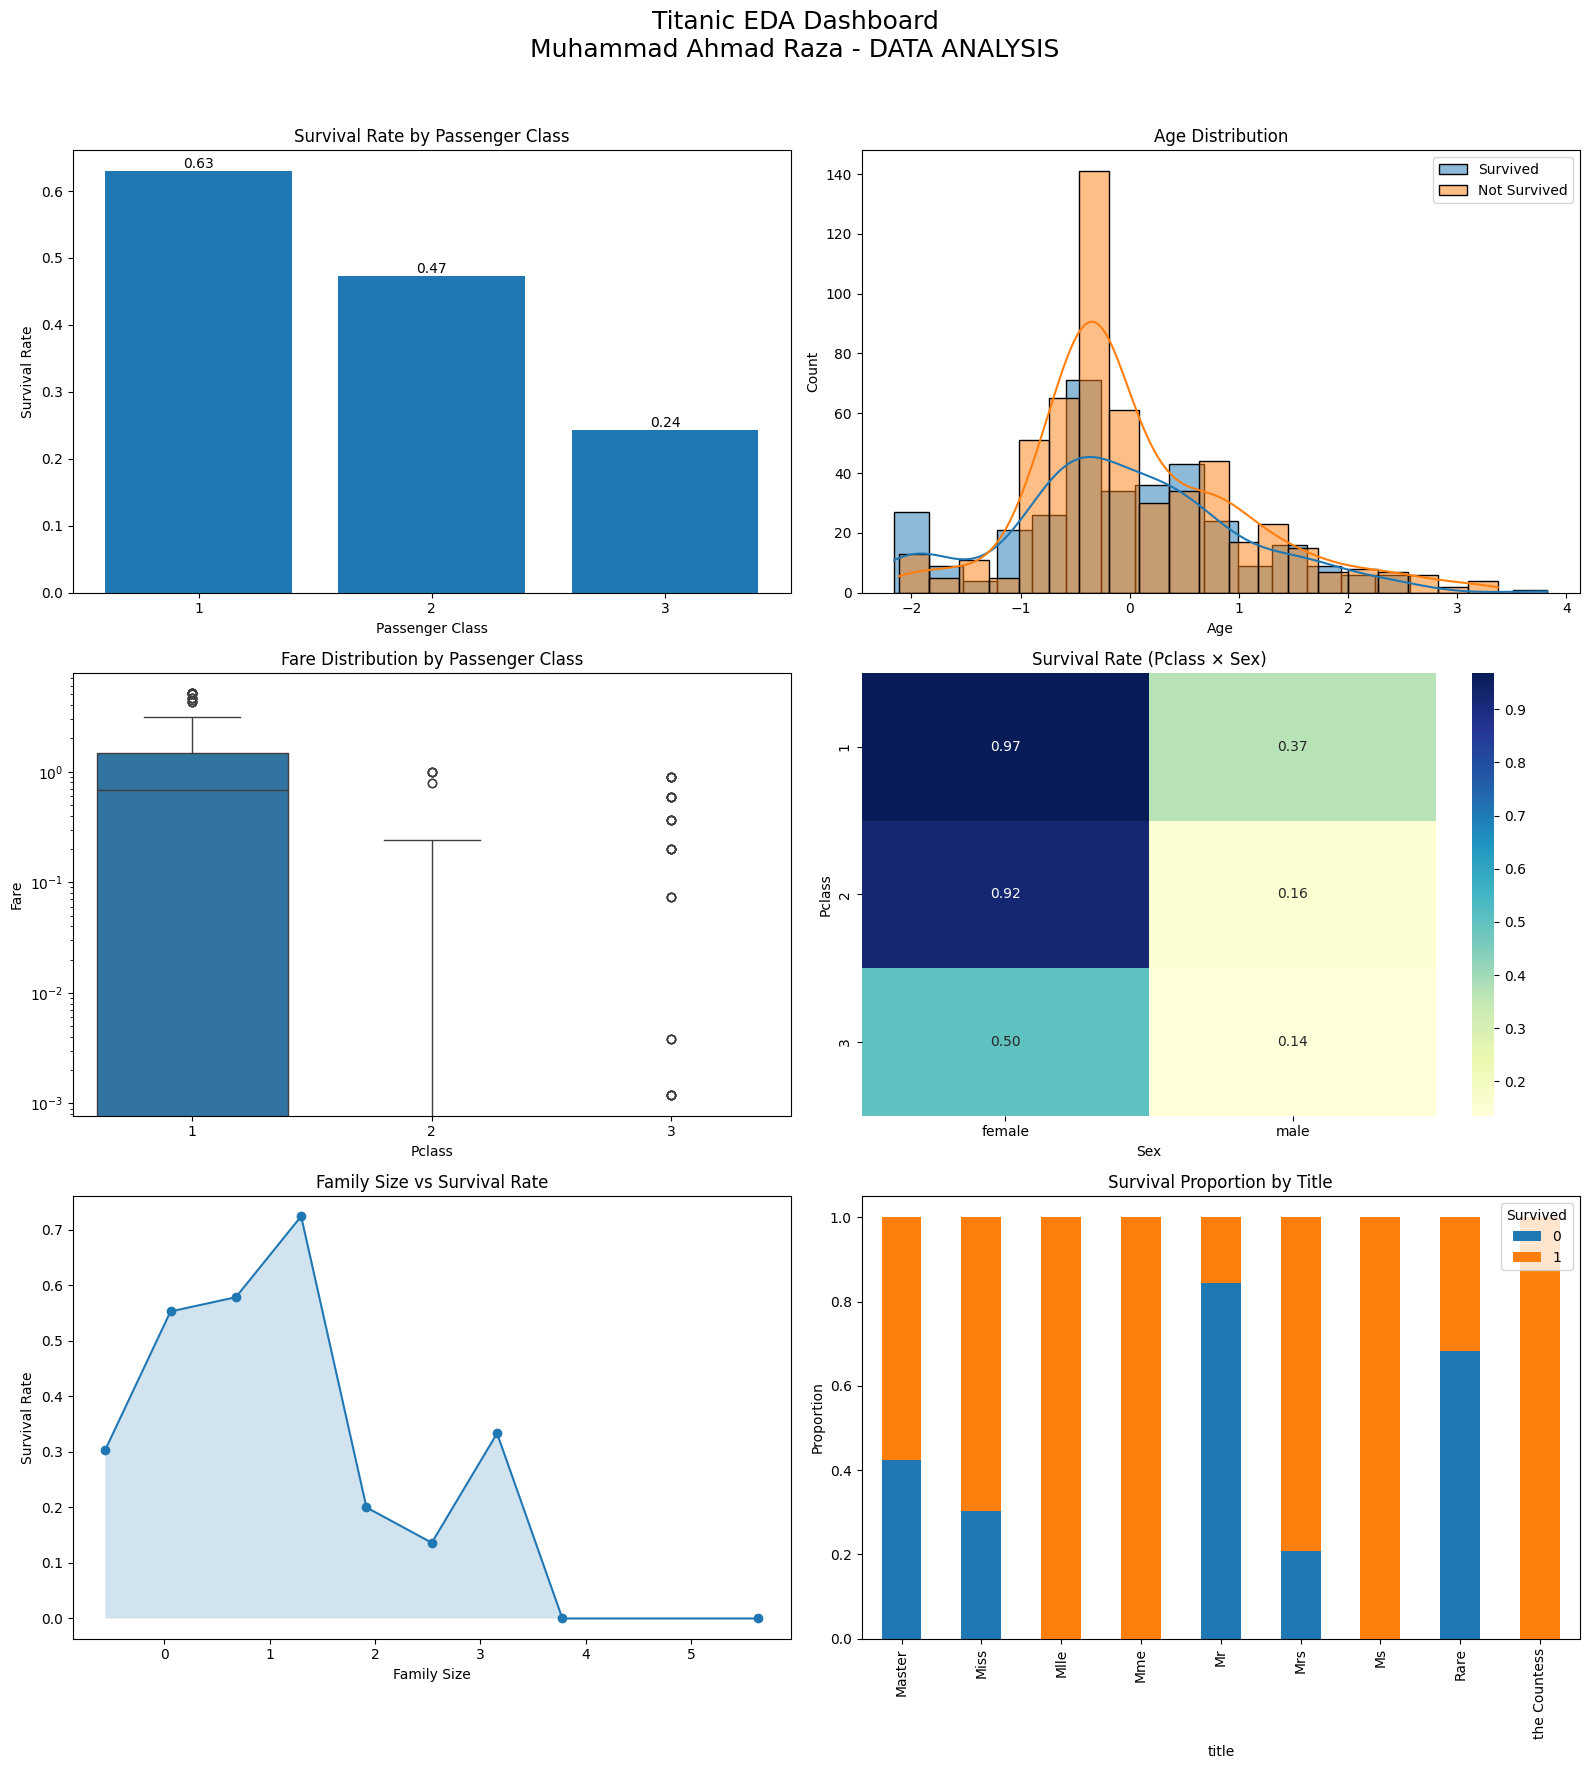

Dashboard saved as 'titanic_dashboard.png'


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------
# Create Dashboard
# ----------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# ====================================================
# Chart 1 - Survival Rate by Passenger Class
# ====================================================
survival_class = df.groupby("Pclass", observed=True)["Survived"].mean()

bars = axes[0, 0].bar(
    survival_class.index.astype(str),
    survival_class.values
)

axes[0, 0].set_title("Survival Rate by Passenger Class")
axes[0, 0].set_xlabel("Passenger Class")
axes[0, 0].set_ylabel("Survival Rate")

# Value labels
for bar in bars:
    axes[0, 0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

# ====================================================
# Chart 2 - Age Distribution
# ====================================================
sns.histplot(
    data=df[df["Survived"] == 1],
    x="Age",
    kde=True,
    label="Survived",
    ax=axes[0,1]
)

sns.histplot(
    data=df[df["Survived"] == 0],
    x="Age",
    kde=True,
    label="Not Survived",
    ax=axes[0,1]
)

axes[0,1].legend()
axes[0,1].set_title("Age Distribution")

# ====================================================
# Chart 3 - Fare by Passenger Class
# ====================================================
sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    ax=axes[1,0]
)

axes[1,0].set_yscale("log")
axes[1,0].set_title("Fare Distribution by Passenger Class")

# ====================================================
# Chart 4 - Heatmap
# ====================================================
pivot = pd.pivot_table(
    df,
    values="Survived",
    index="Pclass",
    columns="Sex",
    aggfunc="mean"
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    ax=axes[1,1]
)

axes[1,1].set_title("Survival Rate (Pclass × Sex)")

# ====================================================
# Chart 5 - Family Size vs Survival
# ====================================================
family_survival = df.groupby("family_size", observed=True)["Survived"].mean()

axes[2,0].plot(
    family_survival.index,
    family_survival.values,
    marker="o"
)

axes[2,0].fill_between(
    family_survival.index,
    family_survival.values,
    alpha=0.2
)

axes[2,0].set_title("Family Size vs Survival Rate")
axes[2,0].set_xlabel("Family Size")
axes[2,0].set_ylabel("Survival Rate")

# ====================================================
# Chart 6 - Survival by Title
# ====================================================
title_survival = pd.crosstab(
    df["title"],
    df["Survived"],
    normalize="index"
)

title_survival.plot(
    kind="bar",
    stacked=True,
    ax=axes[2,1]
)

axes[2,1].set_title("Survival Proportion by Title")
axes[2,1].set_ylabel("Proportion")

# ----------------------------------------------------
# Dashboard Title
# ----------------------------------------------------
plt.suptitle(
    "Titanic EDA Dashboard\nMuhammad Ahmad Raza - DATA ANALYSIS",
    fontsize=18
)

plt.tight_layout(rect=[0,0,1,0.96])

# ----------------------------------------------------
# Save Dashboard
# ----------------------------------------------------
plt.savefig("titanic_dashboard.png", dpi=150)

plt.show()

print("Dashboard saved as 'titanic_dashboard.png'")

In [ ]:
# Titanic Data Analysis Report

## 1. Executive Summary

The Titanic dataset contains information about passengers and whether they survived. The goal of this analysis was to clean the data, create useful features, and find the factors that affected survival. The main findings were that females had a higher survival rate than males, First Class passengers survived more often than Third Class passengers, and fare also influenced survival.

---

## 2. Data Quality Assessment

The dataset contained missing values in the Age, Cabin, and Embarked columns. Age was filled using the median based on Passenger Class and Sex, Embarked was filled with the most common value, and Cabin was replaced with a new feature called `has_cabin` before dropping the original column. These steps made the dataset clean and ready for analysis.

---

## 3. Feature Engineering Rationale

New features were created to improve the dataset. These included family size, whether a passenger was alone, fare per person, passenger title, age group, deck, and fare bin. These features provide more useful information for machine learning models.

---

## 4. Key Statistical Findings

The analysis showed that females had a much higher survival rate than males. First Class passengers survived more often than Second and Third Class passengers. Children generally had better survival rates than adults. Passengers who paid higher fares were also more likely to survive.

---

## 5. Visualization Insights

The charts clearly showed that Passenger Class and Sex had the biggest impact on survival. The heatmap and survival rate charts made these patterns easy to understand. The dashboard provided a clear summary of the entire analysis.

---

## 6. Feature Selection Recommendation

The best features for a future machine learning model are:
- Sex
- Pclass
- Fare
- Age
- Family Size
- Is Alone
- Title

These features showed the strongest relationship with survival.

---

## 7. Reflection

This project helped me understand data cleaning, feature engineering, encoding, feature scaling, GroupBy, pivot tables, correlation, and data visualization. The most challenging part was feature engineering and encoding, but completing this project improved my confidence in using NumPy, Pandas, and Matplotlib for real-world data analysis.